# Fermi/SDSS-V Blazar Analysis Pipeline — Demo

This notebook demonstrates how to use the blazar spectral fitting pipeline
to load pre-computed results from the cache and reproduce all diagnostic
plots for any source in the sample.

The pipeline fits six physically motivated spectral model families to
BOSS optical spectra of Fermi-LAT blazar candidates, measuring optical
jet fractions, spectroscopic redshifts, and equivalent widths.

### Before you start
1. Download the cache from Zenodo: <DOI — to be added upon publication>
2. Place Fits_with_Native_resampling_cache/ in the same directory
3. Install dependencies: pip install -r requirements.txt

### Reference
Nlowie et al. (in prep.) — Optical Spectroscopic Analysis of Fermi
Detected Blazars using SDSS-V

In [68]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, '.')  # adjust if plot_from_cache.py is in a subfolder

import importlib
import blazarkit 
importlib.reload(blazarkit)  # Reload to ensure we have the latest version of the module

from blazarkit import (
    RedshiftResultsCache,
    plot_from_cache,
    plot_multi_object_comparison_single,
    compute_EW_for_all_lines,
    normalize_shape,            
) 

print('Imports successful.')

Imports successful.


## 1. Initialise the cache

The cache contains one compressed file per source in the format
obj_{SDSS_ID}_{MJD}.pkl.gz. Check the cache directory for available
sources and their MJD values.

In [39]:
CACHE_DIR = '/Users/s2822744/Desktop/test_cache' #Update the directory of your cache here 

cache = RedshiftResultsCache(cache_dir=CACHE_DIR)
cached_files = cache.list_cached_objects()

# Show the first 2 cached sources:
print('\nFirst 2 cached sources:')
for f in sorted(cached_files)[:2]:
    print(f'  {f}')

Found 3 cached objects in /Users/s2822744/Desktop/test_cache/

First 2 cached sources:
  obj_13362106_59199.pkl.gz
  obj_15606475_60162.pkl.gz


## 2. Load a single source

Replace SDSS_ID and MJD with any values from the cache above.
The SDSS_ID and MJD are encoded in the filename:
obj_{SDSS_ID}_{MJD}.pkl.gz

In [41]:
SDSS_ID =   '20570296' #your_sdss_id_here  
MJD     = 60027         #Your MJD here         

results = cache.load_object_results(SDSS_ID, mjd=MJD)

# Print a summary of the source
meta  = results['metadata']
lmfit = results['lmfit_results']
comp  = results['components']

print(f"\n{'='*55}")
print(f"SDSS_ID:       {meta['SDSS_ID']}")
print(f"Fermi class:   {meta['fermi_class']}")
print(f"SDSS class:    {meta['obj_class']}")
print(f"Best model:    {lmfit['best_label']}")
print(f"z_fit:         {lmfit['z_best']:.4f}")
print(f"z_SDSS:        {meta['z_sdss']}")
print(f"AICc margin:   {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:      {lmfit['pl_alpha']:.4f}")
print(f"PL delta:      {lmfit['pl_delta']:.4f}")
print(f"S/N:           {meta['sn_median']:.1f}")

# Jet fraction (for combined models)
best = lmfit['best_label']
if best == 'Powerlaw+Galaxy' and comp['galpl_contrib'] is not None:
    print(f"Jet fraction:  {comp['galpl_contrib']['frac_pl']*100:.1f}%")
    print(f"Host fraction: {comp['galpl_contrib']['frac_tpl']*100:.1f}%")
elif best.startswith('Powerlaw+QSO') and comp['qsopl_contrib'] is not None:
    print(f"Jet fraction:  {comp['qsopl_contrib']['frac_pl']*100:.1f}%")
    print(f"Disc/BLR:      {comp['qsopl_contrib']['frac_tpl']*100:.1f}%")
elif best.startswith('Powerlaw+Lines') and comp['linepl_contrib'] is not None:
    print(f"Jet fraction:  {comp['linepl_contrib']['frac_pl']*100:.1f}%")
print(f"{'='*55}")

Loaded: obj_20570296_60027.pkl.gz

SDSS_ID:       20570296
Fermi class:   fsrq
SDSS class:    QSO
Best model:    Powerlaw+Lines (High Blueshift Line)
z_fit:         0.9961
z_SDSS:        0.9996569156646729
AICc margin:   49.0
PL alpha:      -1.2969
PL delta:      -1.2000
S/N:           10.5
Jet fraction:  90.7%


## 3. Default plot — all panels

By default this produces two figures:
- Figure 1: chi2(z) curves and redshift posterior p(z) for all six model families
- Figure 2: best-fit spectrum with component decomposition, line markers,
            zoom insets for detected lines, and normalised residuals

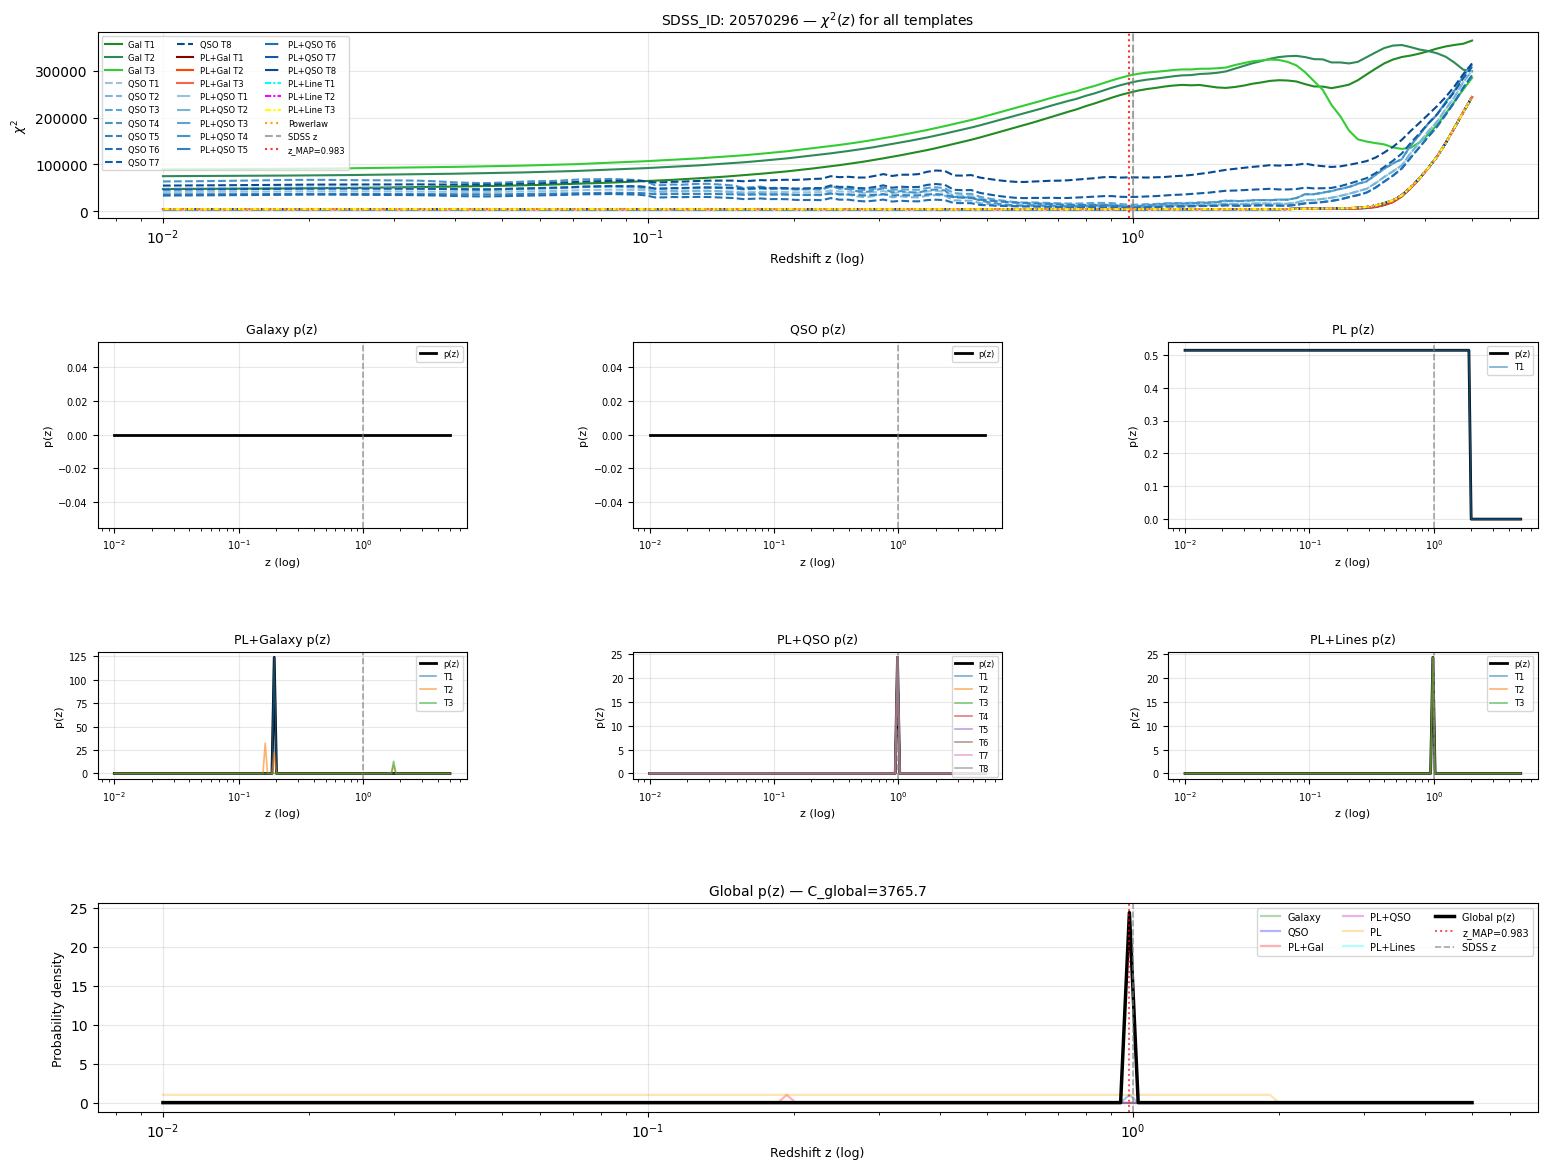

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


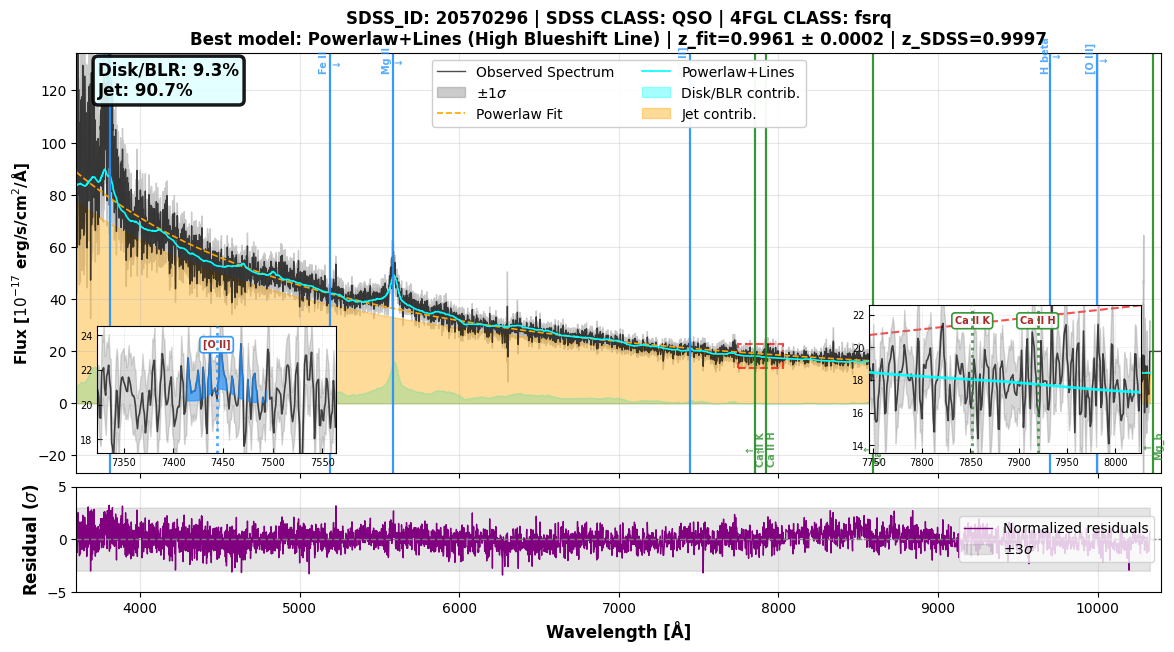


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [46]:

fig1, fig2 = plot_from_cache(results) 

## 4. Customising the plot

All panels are individually controllable via keyword arguments.

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


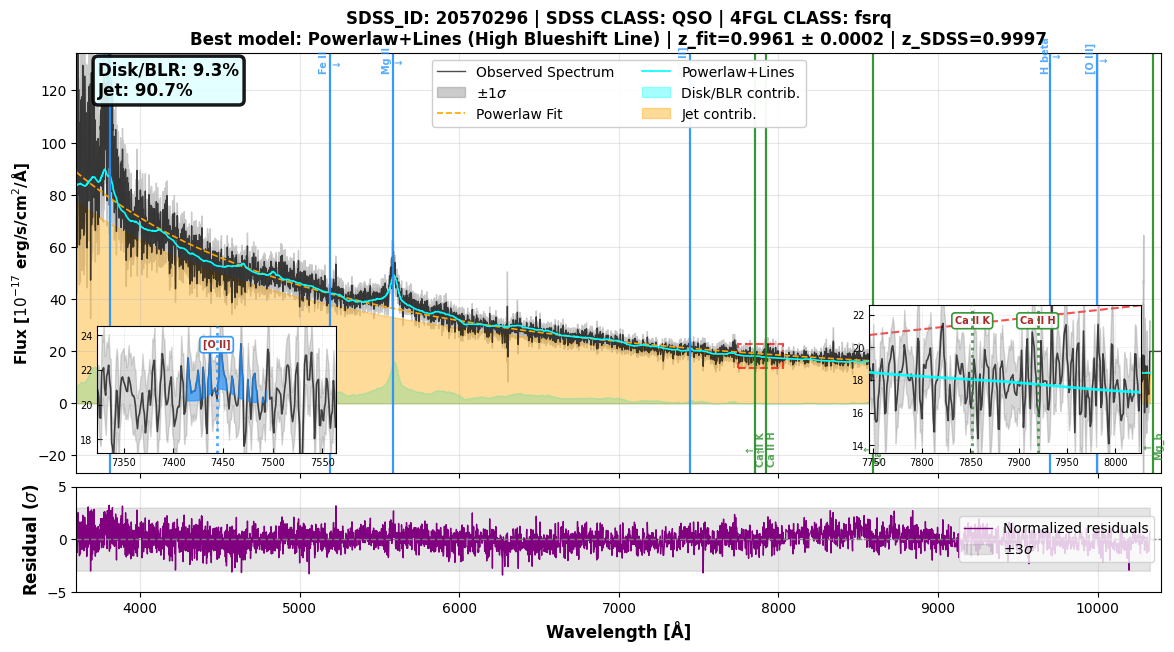


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [47]:

fig1, fig2 = plot_from_cache(results, show_fig1=False)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


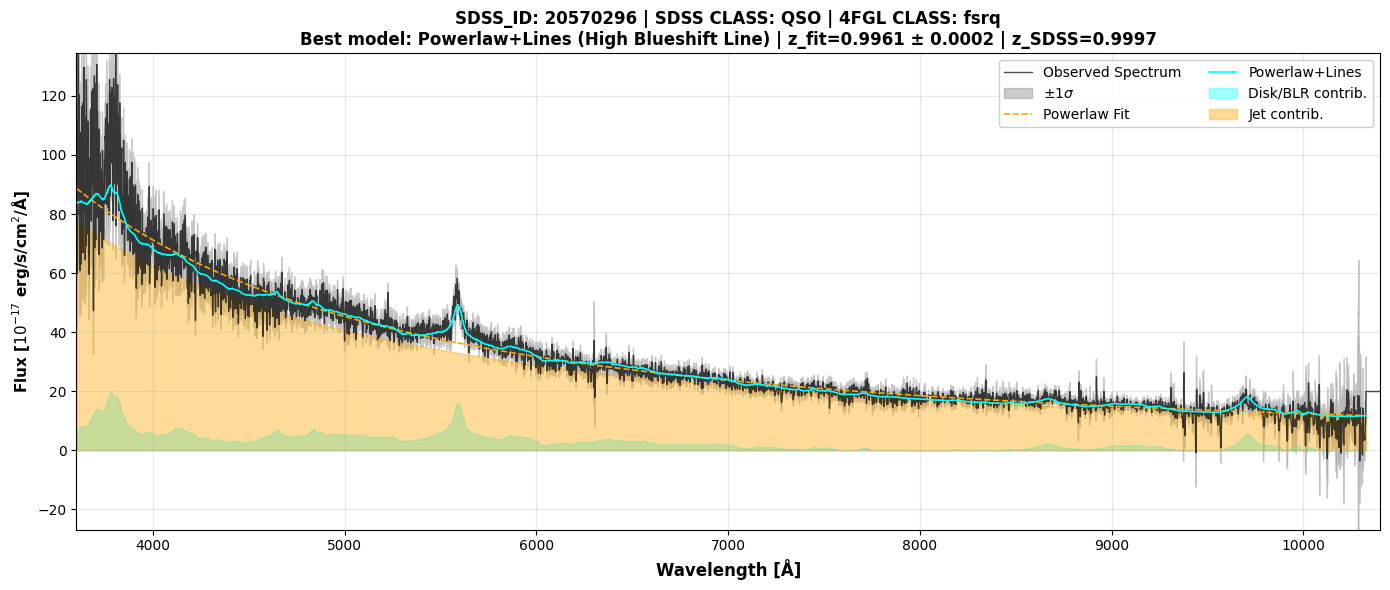


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [48]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1        = False,
    show_inset       = False,
    show_line_markers= False,
    show_residuals   = False,
    show_fraction_label = False,
)

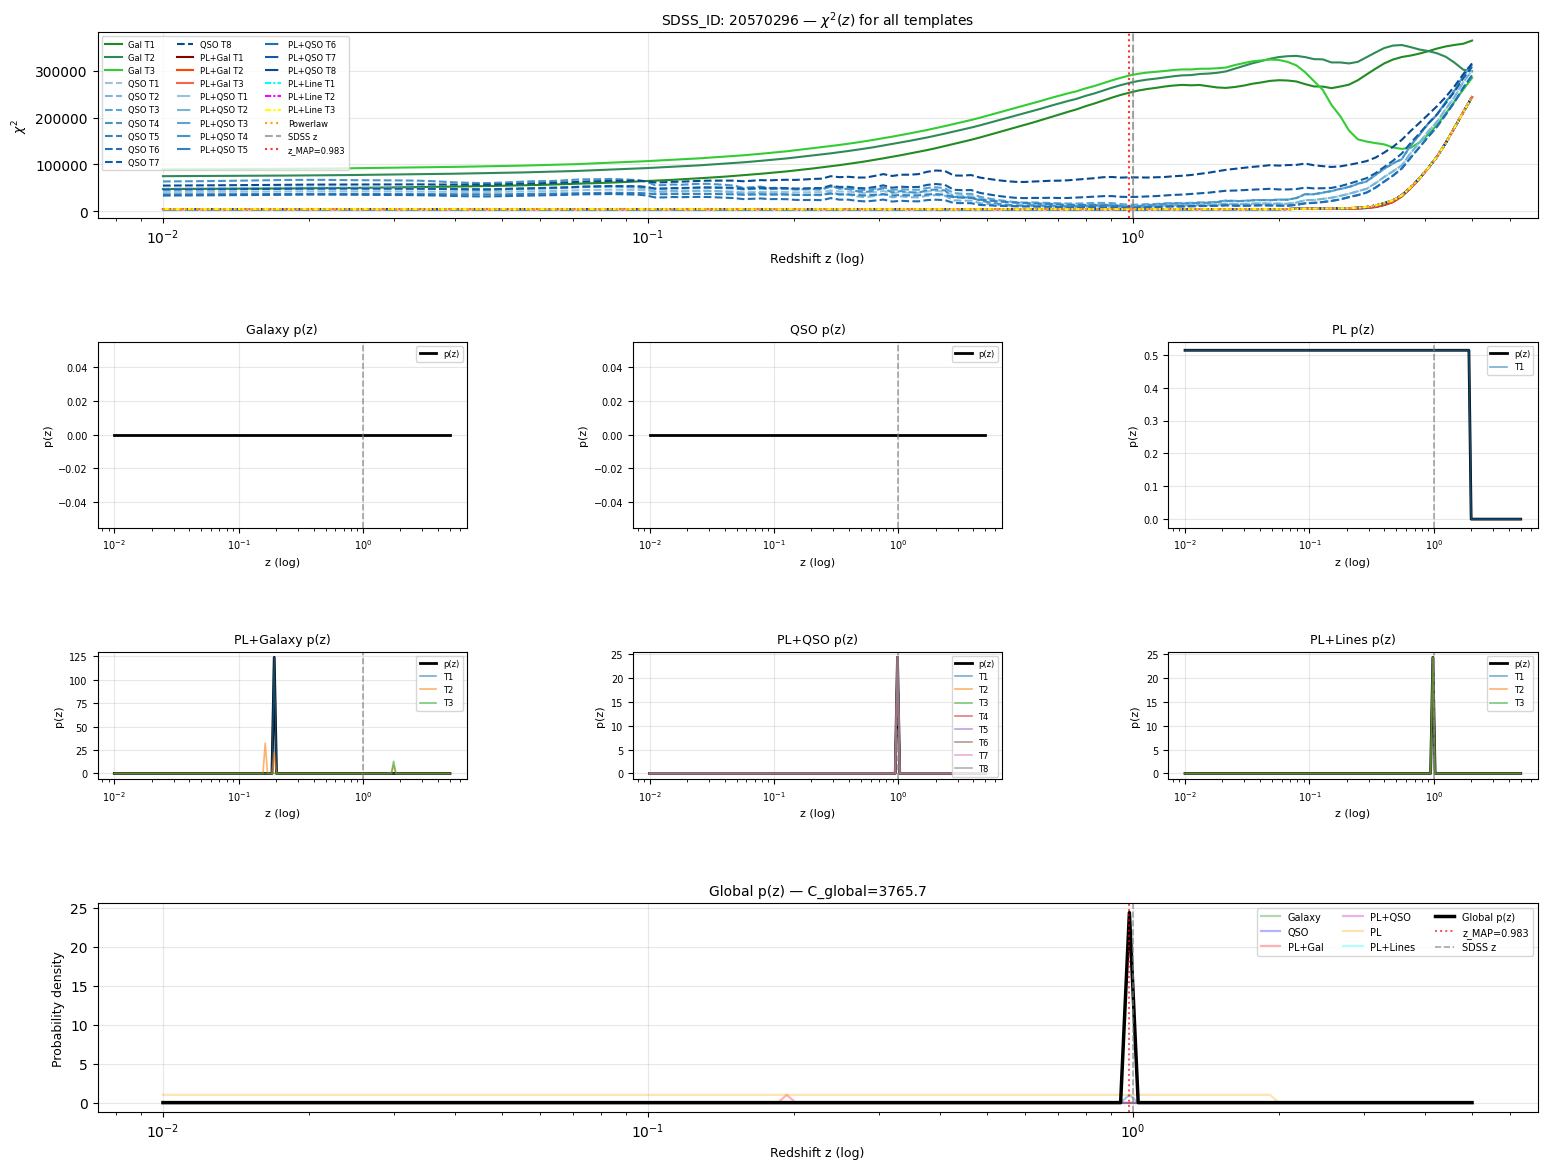

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


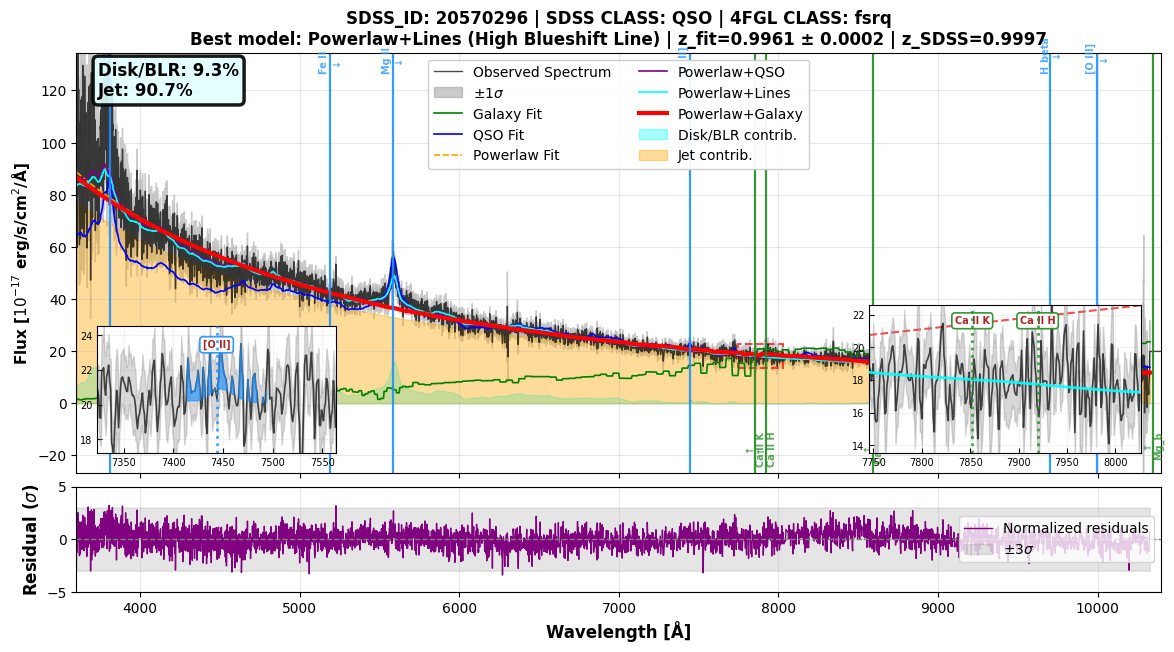


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [49]:
fig1, fig2 = plot_from_cache(results, models_to_show='all')

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


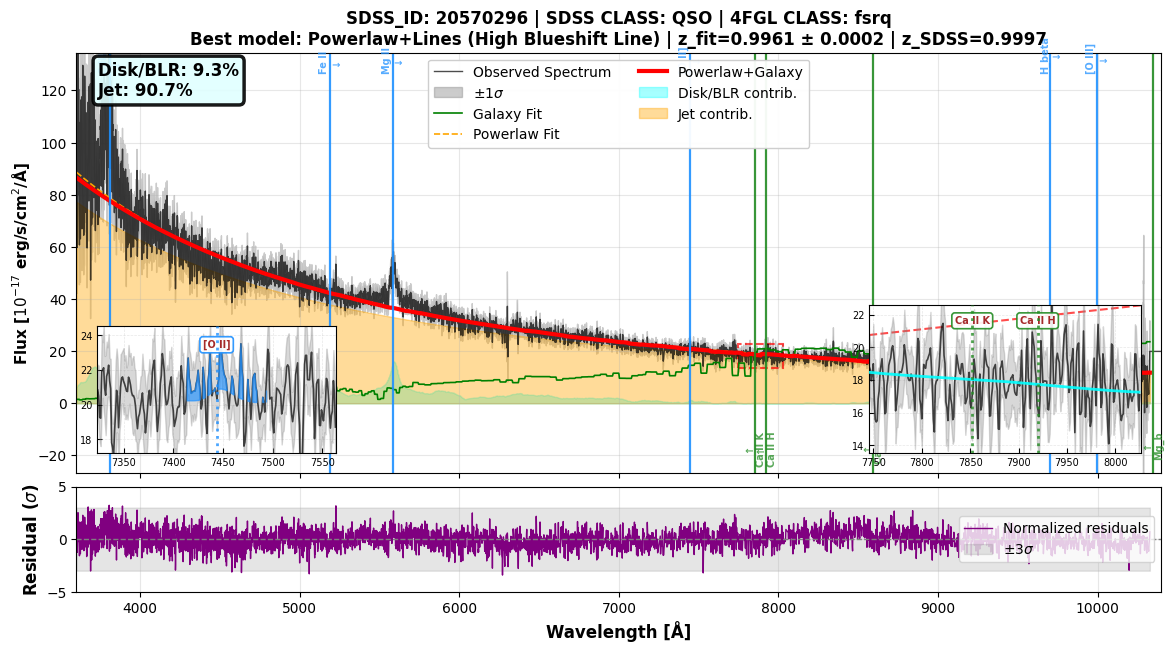


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [50]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1      = False,
    models_to_show = ['Powerlaw+Galaxy', 'Galaxy', 'Powerlaw'],
)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


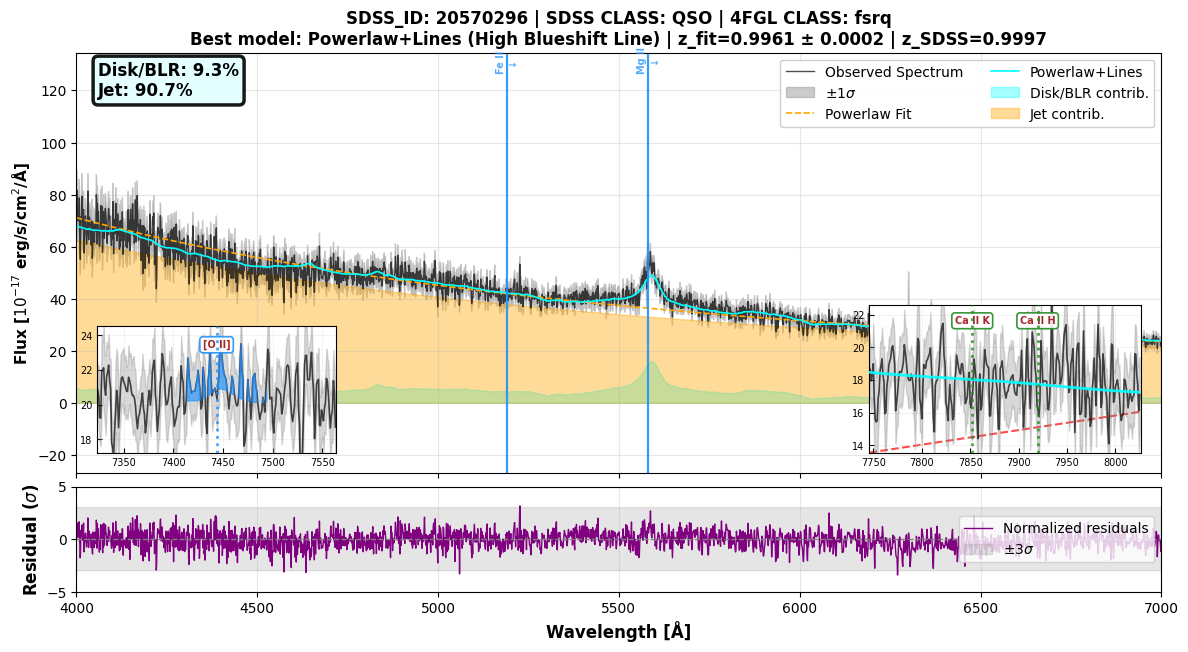


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [51]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1        = False,
    wavelength_range = (4000, 7000),
)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


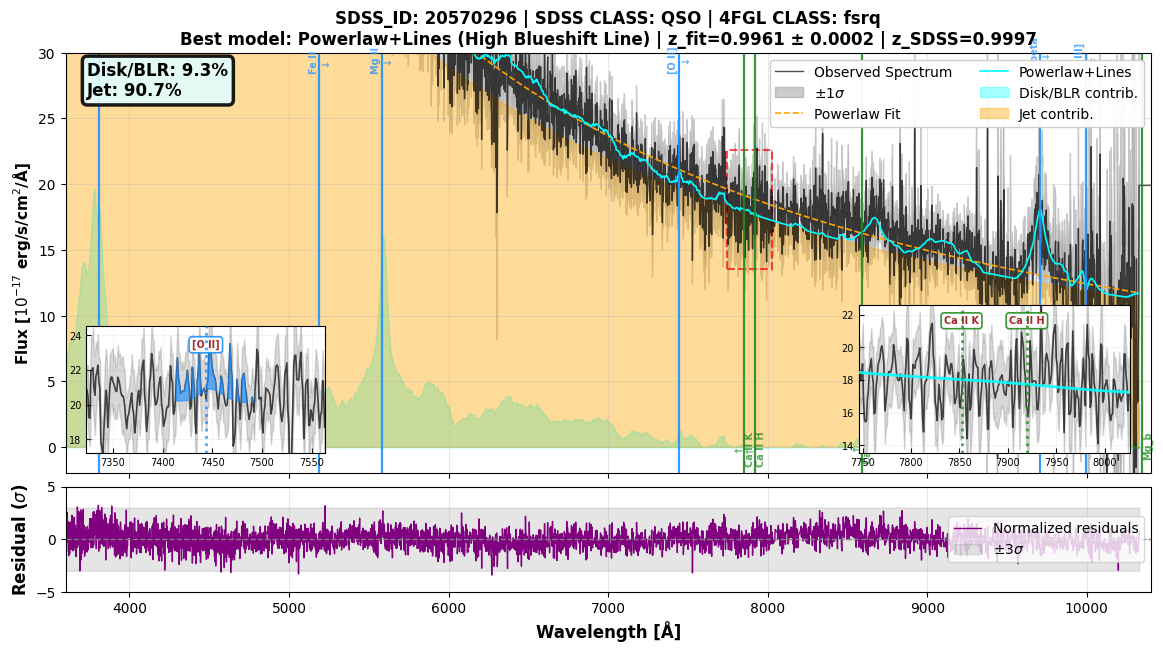


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [52]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1 = False,
    ylim      = (-2, 30),
)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


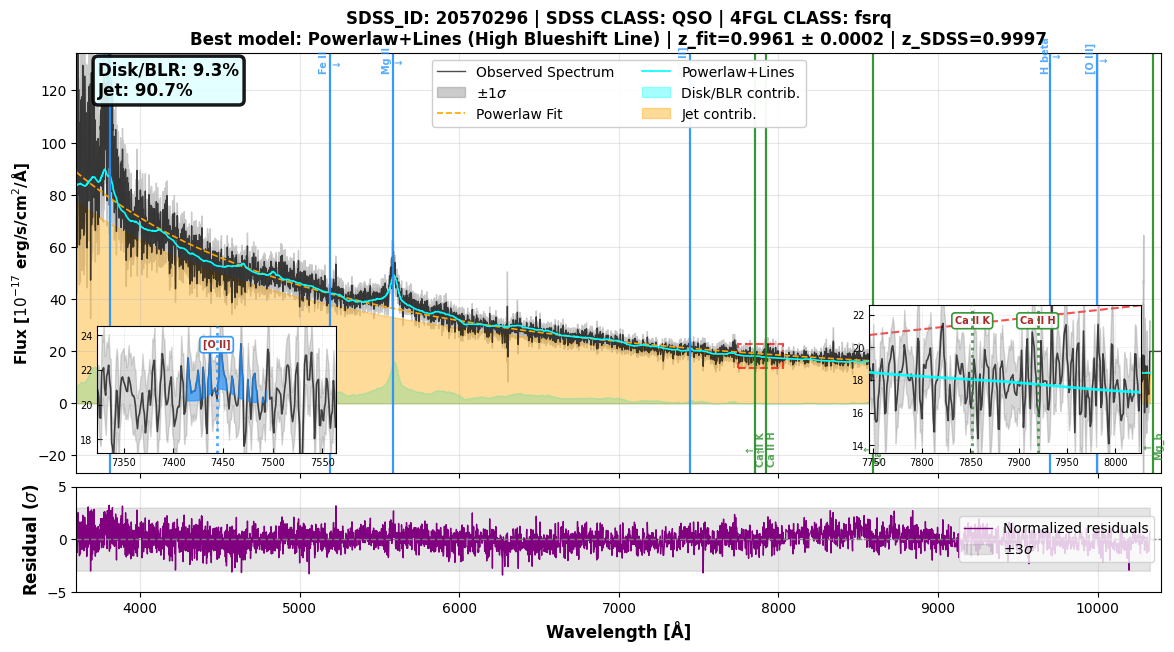

Saved: output_plots/20570296.pdf

SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [53]:
fig1, fig2 = plot_from_cache(results, show_fig1=False, save_dir='output_plots')

## 5. Equivalent width measurements

Equivalent widths are measured for 16 emission and absorption features
using an adaptive integration window that maximises S/N.
A line is considered detected if S/N >= 3.

In [54]:
spec   = results['spectrum']
z_best = results['lmfit_results']['z_best']

results_ew = compute_EW_for_all_lines(
    spec['common_wave'],
    spec['flux_resamp'],
    spec['err_resamp'],
    spec['fit_mask'],
    z_best
)

print(f"Equivalent widths at z = {z_best:.4f}:")
print(f"{'Line':<15} {'Type':<12} {'EW (A)':>10} {'±err':>8} {'S/N':>8} {'Det?':>6} {'Window':>8}")
print("-" * 70)
for name, obs, ew, ew_err, snr, detected, ltype, window in results_ew:
    if np.isfinite(ew):
        flag   = 'yes' if detected else ''
        win_str = f'{window} A' if window is not None else ''
        print(f"{name:<15} {ltype:<12} {ew:>10.2f} {ew_err:>8.2f} "
              f"{snr:>8.1f} {flag:>6} {win_str:>8}")

Equivalent widths at z = 0.9961:
Line            Type             EW (A)     ±err      S/N   Det?   Window
----------------------------------------------------------------------
C III           emission         -20.52     1.34     15.3    yes     50 A
Fe II           emission           1.25     0.45      2.7            20 A
Mg II           emission         -18.37     0.90     20.5    yes     50 A
[O II]          emission          -2.40     0.64      3.7    yes     30 A
H_beta          emission         -25.53     2.20     11.6    yes     80 A
[O III]         emission          -5.80     1.56      3.7    yes     15 A
Ca II K         absorption         2.94     0.84      3.5    yes     30 A
Ca II H         absorption        -2.45     0.87      2.8            30 A
Ca I G          absorption         2.50     0.41      6.0    yes     15 A
Mg_b            absorption         3.32     2.08      1.6            30 A


## 6. Access raw fit parameters

All best-fit parameters from lmfit are stored in the cache and can be
accessed directly for custom analysis.

In [55]:
lmfit = results['lmfit_results']

print("Best-fit parameters:")
print(f"{'Name':<15} {'Value':>12} {'Stderr':>12}")
print("-" * 42)
for name, param in lmfit['best_fit_params']['params'].items():
    val     = param['value']
    err     = param['stderr']
    err_str = f"{err:.4f}" if err is not None else 'N/A'
    print(f"{name:<15} {val:>12.4f} {err_str:>12}")

print(f"\nchi2:        {lmfit['best_fit_params']['chisqr']:.2f}")
print(f"redchi:      {lmfit['best_fit_params']['redchi']:.3f}")
print(f"AICc margin: {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:    {lmfit['pl_alpha']:.4f}")
print(f"PL delta:    {lmfit['pl_delta']:.4f}")

Best-fit parameters:
Name                   Value       Stderr
------------------------------------------
scale_line           83.5800       2.1015
A                    40.6766       0.1422
alpha                -1.2969       0.0318
delta                -1.2000       0.0793
lam0               5000.0000       0.0000
z                     0.9961       0.0002

chi2:        3312.51
redchi:      0.728
AICc margin: 49.0
PL alpha:    -1.2969
PL delta:    -1.2000


## 7. Accessing the redshift posterior

The full p(z) posterior is stored for each source and can be used for
custom redshift analysis or visualisation.

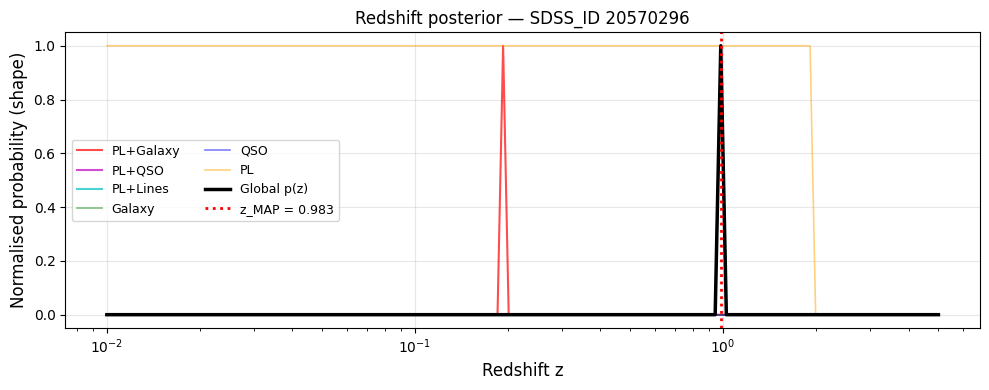

In [59]:
def normalize_shape(p):
    return p / np.max(p) if np.max(p) > 0 else p

pz     = results['pz_results']
z_grid = results['chi2_grids']['z_grid']

fig, ax = plt.subplots(figsize=(10, 4))

# Family contributions — normalised to peak shape only
ax.plot(z_grid, normalize_shape(pz['pz_galpl']),  'r-',  lw=1.5, alpha=0.7, label='PL+Galaxy')
ax.plot(z_grid, normalize_shape(pz['pz_qsopl']),  'm-',  lw=1.5, alpha=0.7, label='PL+QSO')
ax.plot(z_grid, normalize_shape(pz['pz_linepl']), 'c-',  lw=1.5, alpha=0.7, label='PL+Lines')
ax.plot(z_grid, normalize_shape(pz['pz_gal']),    'g-',  lw=1.2, alpha=0.5, label='Galaxy')
ax.plot(z_grid, normalize_shape(pz['pz_qso']),    'b-',  lw=1.2, alpha=0.5, label='QSO')
ax.plot(z_grid, normalize_shape(pz['pz_pl']),     color='orange', lw=1.2, alpha=0.5, label='PL')

# Global posterior — normalised to peak too for consistent scale
ax.plot(z_grid, normalize_shape(pz['p_total']), 'k-', lw=2.5, label='Global p(z)')

ax.axvline(pz['z_map_total'], color='red', ls=':', lw=2,
           label=f"z_MAP = {pz['z_map_total']:.3f}")
ax.set_xscale('log')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Normalised probability (shape)', fontsize=12)
ax.set_title(f"Redshift posterior — SDSS_ID {results['metadata']['SDSS_ID']}")
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

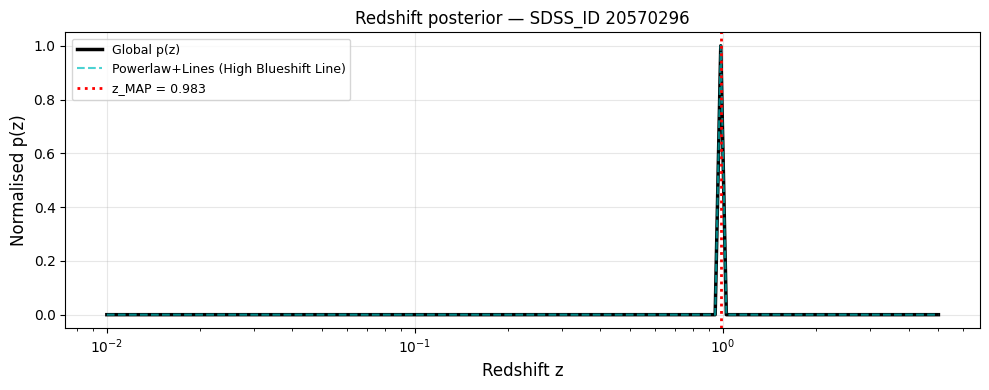

In [74]:
pz     = results['pz_results']
z_grid = results['chi2_grids']['z_grid']

# Map best label to family p(z)
family_pz_map = {
    'Powerlaw+Galaxy' : ('pz_galpl',  'r--'),
    'Powerlaw+QSO'    : ('pz_qsopl',  'm--'),
    'Powerlaw+Lines'  : ('pz_linepl', 'c--'),
    'Galaxy'          : ('pz_gal',    'g--'),
    'QSO'             : ('pz_qso',    'b--'),
    'Powerlaw'        : ('pz_pl',     '--'),
}

best_label = results['lmfit_results']['best_label']
pz_key, style = next(
    ((v[0], v[1]) for k, v in family_pz_map.items() if best_label.startswith(k)),
    ('pz_gal', 'g--')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z_grid, normalize_shape(pz['p_total']), 'k-',  lw=2.5, label='Global p(z)')
ax.plot(z_grid, normalize_shape(pz[pz_key]),    style, lw=1.5, alpha=0.7, label=best_label)
ax.axvline(pz['z_map_total'], color='red', ls=':', lw=2,
           label=f"z_MAP = {pz['z_map_total']:.3f}")
ax.set_xscale('log')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Normalised p(z)', fontsize=12)
ax.set_title(f"Redshift posterior — SDSS_ID {results['metadata']['SDSS_ID']}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# Print top redshift solutions
from blazarkit import get_redshift_peaks

peaks = get_redshift_peaks(pz['p_total'], z_grid, min_height=0.01)
print(peaks)

print(f"\nTop redshift solutions:")
print(f"{'Rank':<6} {'z':>8} {'Rel. height':>12} {'Note'}")
print("-" * 45)
for i, (z_peak, height) in enumerate(peaks[:3]):
    note = 'primary' if i == 0 else f'alternative {i}'
    print(f"{i+1:<6} {z_peak:>8.4f} {height:>12.3f}   {note}")

[(np.float64(0.9829426761503867), 1.0)]

Top redshift solutions:
Rank          z  Rel. height Note
---------------------------------------------
1        0.9829        1.000   primary


In [71]:
p_norm = pz['p_total'] / np.max(pz['p_total'])

# Print all points above 5% of the maximum
above_threshold = z_grid[p_norm > 0.05]
print(f"Redshifts with p(z) > 5% of maximum:")
print(f"  Min: {above_threshold.min():.4f}")
print(f"  Max: {above_threshold.max():.4f}")
print(f"  N points: {len(above_threshold)}")

# Find the value at the visual second peak location
# Replace 0.5 with the approximate redshift where you see the second peak
z_approx = 0.5  # ← change this
idx = np.argmin(np.abs(z_grid - z_approx))
print(f"\nAt z={z_approx}: p_norm = {p_norm[idx]:.4f}")

Redshifts with p(z) > 5% of maximum:
  Min: 0.9829
  Max: 0.9829
  N points: 1

At z=0.5: p_norm = 0.0000


## 8. Loop over all sources in the cache

You can iterate over all cached sources to extract statistics or
reproduce plots in bulk.

In [57]:
# Extract key parameters from all cached sources
summary = []

for fname in sorted(cache.list_cached_objects()):
    # Parse SDSS_ID and MJD from filename
    parts   = fname.replace('.pkl.gz', '').split('_')
    sdss_id = parts[1]
    mjd     = int(parts[2]) if len(parts) > 2 else None

    try:
        res   = cache.load_object_results(sdss_id, mjd=mjd)
        lm    = res['lmfit_results']
        m     = res['metadata']
        c     = res['components']

        jet_frac = np.nan
        if lm['best_label'] == 'Powerlaw+Galaxy' and c['galpl_contrib']:
            jet_frac = c['galpl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+QSO') and c['qsopl_contrib']:
            jet_frac = c['qsopl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+Lines') and c['linepl_contrib']:
            jet_frac = c['linepl_contrib']['frac_pl']

        summary.append({
            'SDSS_ID'    : sdss_id,
            'MJD'        : mjd,
            'best_label' : lm['best_label'],
            'z_best'     : lm['z_best'],
            'z_sdss'     : m['z_sdss'],
            'fermi_class': m['fermi_class'],
            'jet_frac'   : jet_frac,
            'pl_alpha'   : lm['pl_alpha'],
            'aicc_margin': lm['aicc_margin'],
            'sn'         : m['sn_median'],
        })
    except Exception as e:
        print(f"  Skipped {fname}: {e}")

print(f"\nLoaded {len(summary)} sources")

# Convert to arrays for analysis
z_best   = np.array([s['z_best']   for s in summary])
jet_frac = np.array([s['jet_frac'] for s in summary])
pl_alpha = np.array([s['pl_alpha'] for s in summary])

print(f"Median z_best:    {np.nanmedian(z_best):.3f}")
print(f"Median jet frac:  {np.nanmedian(jet_frac[np.isfinite(jet_frac)]):.3f}")
print(f"Median PL alpha:  {np.nanmedian(pl_alpha[np.isfinite(pl_alpha)]):.3f}")

Found 3 cached objects in /Users/s2822744/Desktop/test_cache/
Loaded: obj_13362106_59199.pkl.gz
Loaded: obj_15606475_60162.pkl.gz
Loaded: obj_20570296_60027.pkl.gz

Loaded 3 sources
Median z_best:    0.674
Median jet frac:  0.601
Median PL alpha:  -0.389


## 9. Multi-object comparison plot

Plot multiple sources side by side for visual comparison.
Requires the main blazar sample table (VAC).

In [ ]:
from astropy.table import Table
from astropy.io import fits

# Load the VAC table — update path as needed
vac = Table(fits.open('fermi_blazar_vac_dr20.fits')[1].data)
print(f"VAC: {len(vac)} sources")

# Select a few sources to compare — e.g. high S/N BL Lac candidates
# Adjust column names to match your VAC
object_list = [
    {'SDSS_ID': int(row['SDSS_ID']), 'MJD': None}
    for row in vac[:4]   # replace with your selection
]

fig = plot_multi_object_comparison_single(
    object_list = object_list,
    cache       = cache,
    final_bl    = vac,
    n_cols      = 2,
    save_dir    = 'output_plots'
) 

